# Regresión — Housing Prices
Pipeline completo: limpieza → selección de características → escalado → modelo → validación cruzada → gráficas

## 1. Carga del dataset

In [13]:
import pandas as pd

df = pd.read_csv('real_estate_dataset.csv')
df = df.drop(columns=['ID'])
df.head()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


## 2. Revisión de nulos

In [14]:
df.isnull().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

## 3. Revisión de columnas de texto

In [15]:
df.dtypes

Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Year_Built              int64
Has_Garden              int64
Has_Pool                int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object

## 4. Selección de características

### Método 1 — Matriz de Correlación

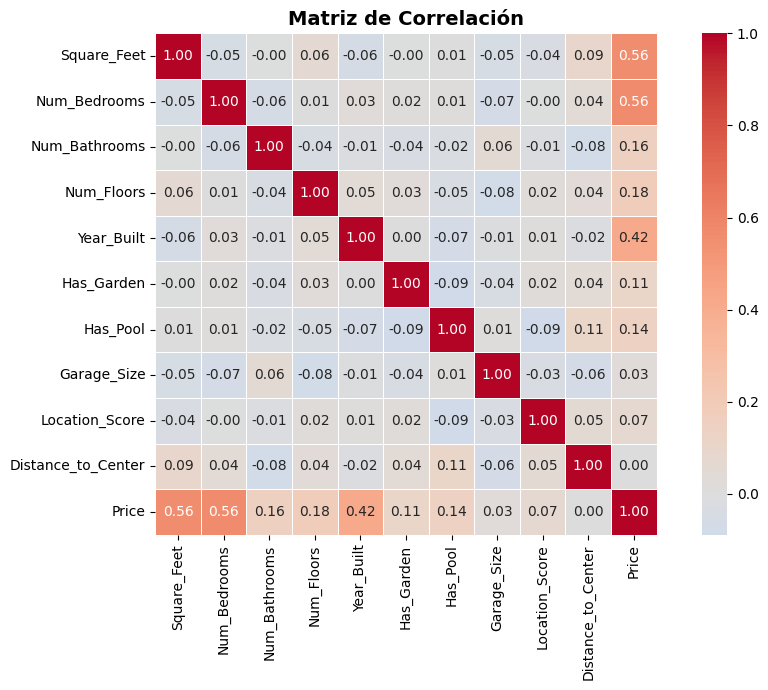


Correlación con Price (ordenada):
Num_Bedrooms          0.563973
Square_Feet           0.558604
Year_Built            0.418293
Num_Floors            0.177435
Num_Bathrooms         0.156689
Has_Pool              0.136579
Has_Garden            0.109196
Location_Score        0.071326
Garage_Size           0.032100
Distance_to_Center    0.000730


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr_price = corr['Price'].drop('Price').abs().sort_values(ascending=False)
top_corr = corr_price.head(5).index.tolist()
print("\nCorrelación con Price (ordenada):")
print(corr['Price'].drop('Price').sort_values(ascending=False).to_string())

### Método 2 — RFE (Recursive Feature Elimination)

In [17]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = df.drop(columns=['Price'])
y = df['Price']

rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X, y)

ranking_rfe = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_,
    'Seleccionada': rfe.support_
}).sort_values('Ranking')

print(ranking_rfe.to_string(index=False))

top_rfe = ranking_rfe[ranking_rfe['Seleccionada']]['Feature'].tolist()
print(f"\nTop 5 por RFE: {top_rfe}")

           Feature  Ranking  Seleccionada
      Num_Bedrooms        1          True
     Num_Bathrooms        1          True
        Num_Floors        1          True
        Has_Garden        1          True
          Has_Pool        1          True
    Location_Score        2         False
        Year_Built        3         False
       Garage_Size        4         False
Distance_to_Center        5         False
       Square_Feet        6         False

Top 5 por RFE: ['Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Has_Garden', 'Has_Pool']


### Método 3 — Feature Importance (Random Forest Regressor)

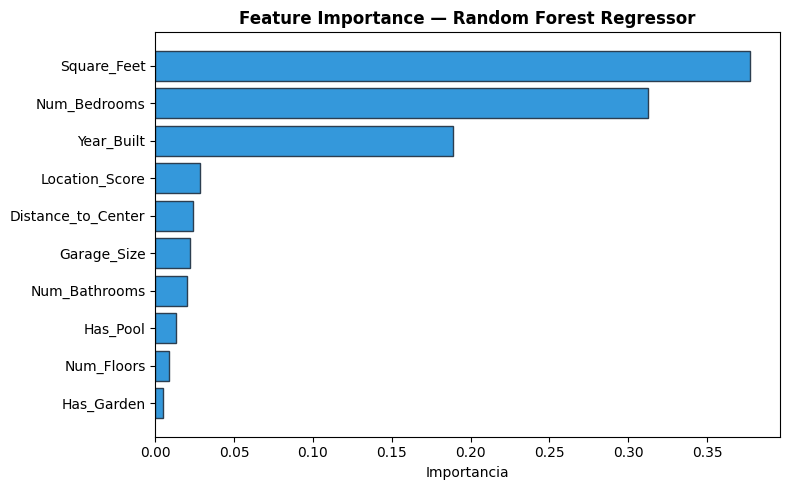

Top 5 por Random Forest: ['Square_Feet', 'Num_Bedrooms', 'Year_Built', 'Location_Score', 'Distance_to_Center']


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importancia = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importancia['Feature'], importancia['Importancia'], color='#3498db', edgecolor='#2c3e50')
plt.xlabel('Importancia')
plt.title('Feature Importance — Random Forest Regressor', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_rf = importancia.head(5)['Feature'].tolist()
print(f"Top 5 por Random Forest: {top_rf}")

### Comparación de los 3 métodos

In [19]:
from collections import Counter

todas = top_corr + top_rfe + top_rf
conteo = Counter(todas)

comparacion = pd.DataFrame({
    'Feature': X.columns,
    'Correlación': ['✓' if f in top_corr else '' for f in X.columns],
    'RFE': ['✓' if f in top_rfe else '' for f in X.columns],
    'RandomForest': ['✓' if f in top_rf else '' for f in X.columns],
    'Votos': [conteo.get(f, 0) for f in X.columns]
}).sort_values('Votos', ascending=False)

print(comparacion.to_string(index=False))

           Feature Correlación RFE RandomForest  Votos
      Num_Bedrooms           ✓   ✓            ✓      3
       Square_Feet           ✓                ✓      2
     Num_Bathrooms           ✓   ✓                   2
        Num_Floors           ✓   ✓                   2
        Year_Built           ✓                ✓      2
        Has_Garden               ✓                   1
          Has_Pool               ✓                   1
    Location_Score                            ✓      1
Distance_to_Center                            ✓      1
       Garage_Size                                   0


### Selección de características

In [20]:
X = df.drop(columns=['Price'])
y = df['Price']
X.columns.tolist()

['Square_Feet',
 'Num_Bedrooms',
 'Num_Bathrooms',
 'Num_Floors',
 'Year_Built',
 'Has_Garden',
 'Has_Pool',
 'Garage_Size',
 'Location_Score',
 'Distance_to_Center']

## 5. Escalado de datos

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Modelo de Regresión Lineal
Se utiliza **LinearRegression** de scikit-learn, un modelo que busca la relación lineal entre las features y el precio minimizando la suma de errores cuadrados.

### Cross-Validation (7 corridas)

In [22]:
from sklearn.model_selection import cross_validate

modelo = LinearRegression()
scoring = {'R2': 'r2', 'MAE': 'neg_mean_absolute_error'}
cv = cross_validate(modelo, X_scaled, y, cv=7, scoring=scoring)

r2 = cv['test_R2']
mae = -cv['test_MAE']

print(f"{'Corrida':<10} {'R²':>10} {'MAE':>15}")
print("-" * 35)
for i in range(7):
    print(f"  {i+1:<8} {r2[i]:>10.4f} {mae[i]:>15.2f}")
print("-" * 35)
print(f"{'Promedio':<10} {r2.mean():>10.4f} {mae.mean():>15.2f}")

Corrida            R²             MAE
-----------------------------------
  1            0.9812        12850.34
  2            0.9783        14253.11
  3            0.9745        16152.94
  4            0.9719        15650.91
  5            0.9750        15994.27
  6            0.9702        17918.76
  7            0.9732        15932.40
-----------------------------------
Promedio       0.9749        15536.10


### Corrida única — Dispersión y Distribución de residuos

R²: 0.9709  |  MAE: 16851.00


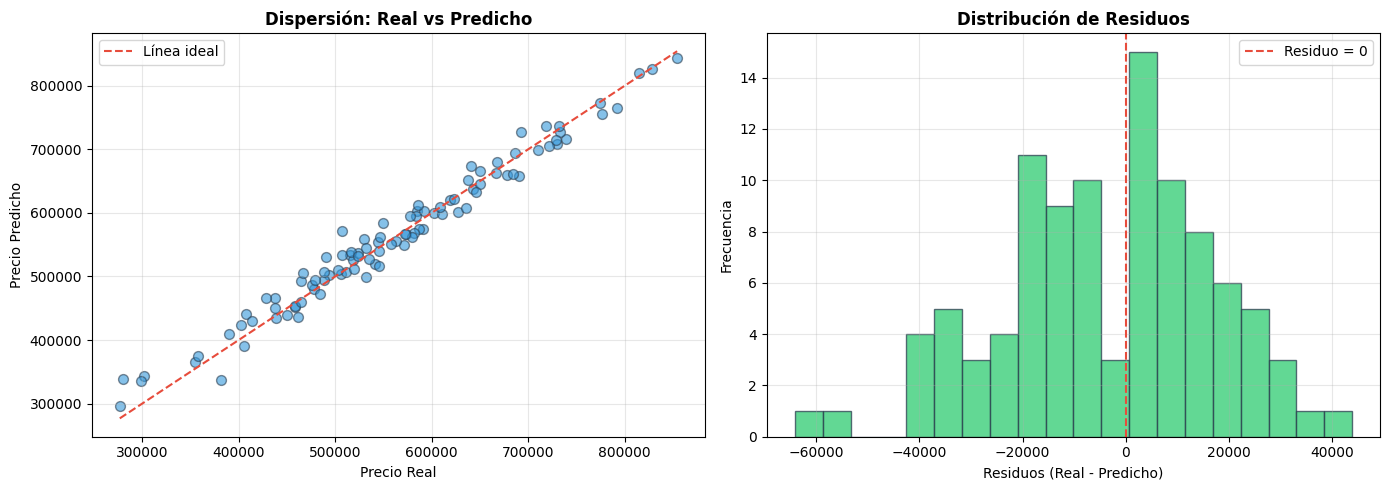

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

modelo_final = LinearRegression()
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)
residuos = y_test - y_pred

print(f"R²: {r2_score(y_test, y_pred):.4f}  |  MAE: {mean_absolute_error(y_test, y_pred):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='#2c3e50', facecolors='#3498db', s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, '--', color='#e74c3c', lw=1.5, label='Línea ideal')
axes[0].set_xlabel('Precio Real')
axes[0].set_ylabel('Precio Predicho')
axes[0].set_title('Dispersión: Real vs Predicho', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuos, bins=20, edgecolor='#2c3e50', facecolor='#2ecc71', alpha=0.75)
axes[1].axvline(0, color='#e74c3c', ls='--', lw=1.5, label='Residuo = 0')
axes[1].set_xlabel('Residuos (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Exportar modelo para despliegue

In [24]:
import joblib

joblib.dump(modelo_final, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Modelo guardado: model.pkl')
print('Escalador guardado: scaler.pkl')

Modelo guardado: model.pkl
Escalador guardado: scaler.pkl
